In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir('/content/drive/MyDrive'))

['download.jpeg', 'Colab Notebooks', 'plantdisease.zip', 'plantdisease', 'Transformer Architecture Diagram & Overview.gdoc']


In [4]:
import zipfile
import os

dataset_zip = "/content/drive/MyDrive/plantdisease.zip"
extract_path = "/content/plantdisease"

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['plantvillage dataset']


In [ ]:
import os

print(
    os.listdir(
        "/content/plantdisease/plantvillage dataset"
    )
)

['segmented', 'grayscale', 'color']


In [ ]:
color_path = "/content/plantdisease/plantvillage dataset/color"

print(
    "Number of disease classes:",
    len(os.listdir(color_path))
)

print(
    "\nFirst 10 classes:"
)

for folder in os.listdir(color_path)[:10]:
    print(folder)

Number of disease classes: 38

First 10 classes:
Potato___healthy
Apple___Black_rot
Tomato___healthy
Soybean___healthy
Apple___healthy
Apple___Cedar_apple_rust
Pepper,_bell___healthy
Tomato___Tomato_mosaic_virus
Tomato___Target_Spot
Squash___Powdery_mildew


In [ ]:
# ============================================================
# CHECK THE COLOR DATASET
# ============================================================

from pathlib import Path
import os

COLOR_DIR = Path(
    "/content/plantdisease/plantvillage dataset/color"
)

# Get all class folders
class_folders = sorted([
    folder
    for folder in COLOR_DIR.iterdir()
    if folder.is_dir()
])

print("Color dataset path:")
print(COLOR_DIR)

print("\nNumber of classes:", len(class_folders))

print("\nAll 38 classes:")
for i, folder in enumerate(class_folders, 1):
    print(f"{i:02d}. {folder.name}")

Color dataset path:
/content/plantdisease/plantvillage dataset/color

Number of classes: 38

All 38 classes:
01. Apple___Apple_scab
02. Apple___Black_rot
03. Apple___Cedar_apple_rust
04. Apple___healthy
05. Blueberry___healthy
06. Cherry_(including_sour)___Powdery_mildew
07. Cherry_(including_sour)___healthy
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
09. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tom

In [ ]:
# ============================================================
# COUNT IMAGES IN EACH CLASS
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

class_counts = {}

for folder in class_folders:

    count = 0

    for file in folder.rglob("*"):

        if (
            file.is_file()
            and file.suffix.lower()
            in IMAGE_EXTENSIONS
        ):
            count += 1

    class_counts[folder.name] = count


total_images = sum(
    class_counts.values()
)

print("Total images:", total_images)

print("\nImages in each class:\n")

for class_name, count in class_counts.items():

    print(
        f"{class_name}: {count}"
    )

Total images: 54305

Images in each class:

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___Powdery_mildew: 1052
Cherry_(including_sour)___healthy: 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___Northern_Leaf_Blight: 985
Corn_(maize)___healthy: 1162
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Grape___healthy: 423
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___Leaf_scorch: 1109
Strawberry___healthy: 456
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___Late_blight: 19

In [ ]:
# ============================================================
# CREATE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# Dataset location
COLOR_DIR = Path(
    "/content/plantdisease/plantvillage dataset/color"
)

# Image extensions
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# Collect image paths and labels
image_paths = []
labels = []

for class_folder in sorted(COLOR_DIR.iterdir()):

    if not class_folder.is_dir():
        continue

    class_name = class_folder.name

    for image_file in class_folder.iterdir():

        if (
            image_file.is_file()
            and image_file.suffix.lower()
            in IMAGE_EXTENSIONS
        ):
            image_paths.append(str(image_file))
            labels.append(class_name)

# Create dataframe
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

# ------------------------------------------------------------
# First split:
# 70% training
# 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# ------------------------------------------------------------
# Second split:
# 15% validation
# 15% testing
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n========================================")
print("DATASET SPLIT")
print("========================================")

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Total images: 54305
Total classes: 38

DATASET SPLIT
Training images   : 38013
Validation images : 8146
Testing images    : 8146

Total: 54305


In [ ]:
# ============================================================
# CHECK CLASS DISTRIBUTION
# ============================================================

print("Training classes   :", train_df["label"].nunique())
print("Validation classes :", val_df["label"].nunique())
print("Testing classes    :", test_df["label"].nunique())

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

Training classes   : 38
Validation classes : 38
Testing classes    : 38

Training distribution:
label
Apple___Apple_scab                                     441
Apple___Black_rot                                      435
Apple___Cedar_apple_rust                               193
Apple___healthy                                       1152
Blueberry___healthy                                   1051
Cherry_(including_sour)___Powdery_mildew               736
Cherry_(including_sour)___healthy                      598
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     359
Corn_(maize)___Common_rust_                            834
Corn_(maize)___Northern_Leaf_Blight                    690
Corn_(maize)___healthy                                 813
Grape___Black_rot                                      826
Grape___Esca_(Black_Measles)                           968
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)             753
Grape___healthy                                        296
Orange___Haun

In [ ]:
# ============================================================
# CREATE CLASS LABELS
# ============================================================

class_names = sorted(df["label"].unique())

print("Number of classes:", len(class_names))
print("\nClass mapping:")

for i, name in enumerate(class_names):
    print(i, "→", name)

class_to_index = {
    name: index
    for index, name in enumerate(class_names)
}

index_to_class = {
    index: name
    for name, index in class_to_index.items()
}

# Convert labels to numbers
train_df["label_id"] = train_df["label"].map(class_to_index)
val_df["label_id"] = val_df["label"].map(class_to_index)
test_df["label_id"] = test_df["label"].map(class_to_index)

print("Number of classes:", len(class_names))

print("\nClass mapping:")

for index, name in index_to_class.items():
    print(f"{index:02d} → {name}")

Number of classes: 38

Class mapping:
0 → Apple___Apple_scab
1 → Apple___Black_rot
2 → Apple___Cedar_apple_rust
3 → Apple___healthy
4 → Blueberry___healthy
5 → Cherry_(including_sour)___Powdery_mildew
6 → Cherry_(including_sour)___healthy
7 → Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 → Corn_(maize)___Common_rust_
9 → Corn_(maize)___Northern_Leaf_Blight
10 → Corn_(maize)___healthy
11 → Grape___Black_rot
12 → Grape___Esca_(Black_Measles)
13 → Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 → Grape___healthy
15 → Orange___Haunglongbing_(Citrus_greening)
16 → Peach___Bacterial_spot
17 → Peach___healthy
18 → Pepper,_bell___Bacterial_spot
19 → Pepper,_bell___healthy
20 → Potato___Early_blight
21 → Potato___Late_blight
22 → Potato___healthy
23 → Raspberry___healthy
24 → Soybean___healthy
25 → Squash___Powdery_mildew
26 → Strawberry___Leaf_scorch
27 → Strawberry___healthy
28 → Tomato___Bacterial_spot
29 → Tomato___Early_blight
30 → Tomato___Late_blight
31 → Tomato___Leaf_Mold
32 → Tom

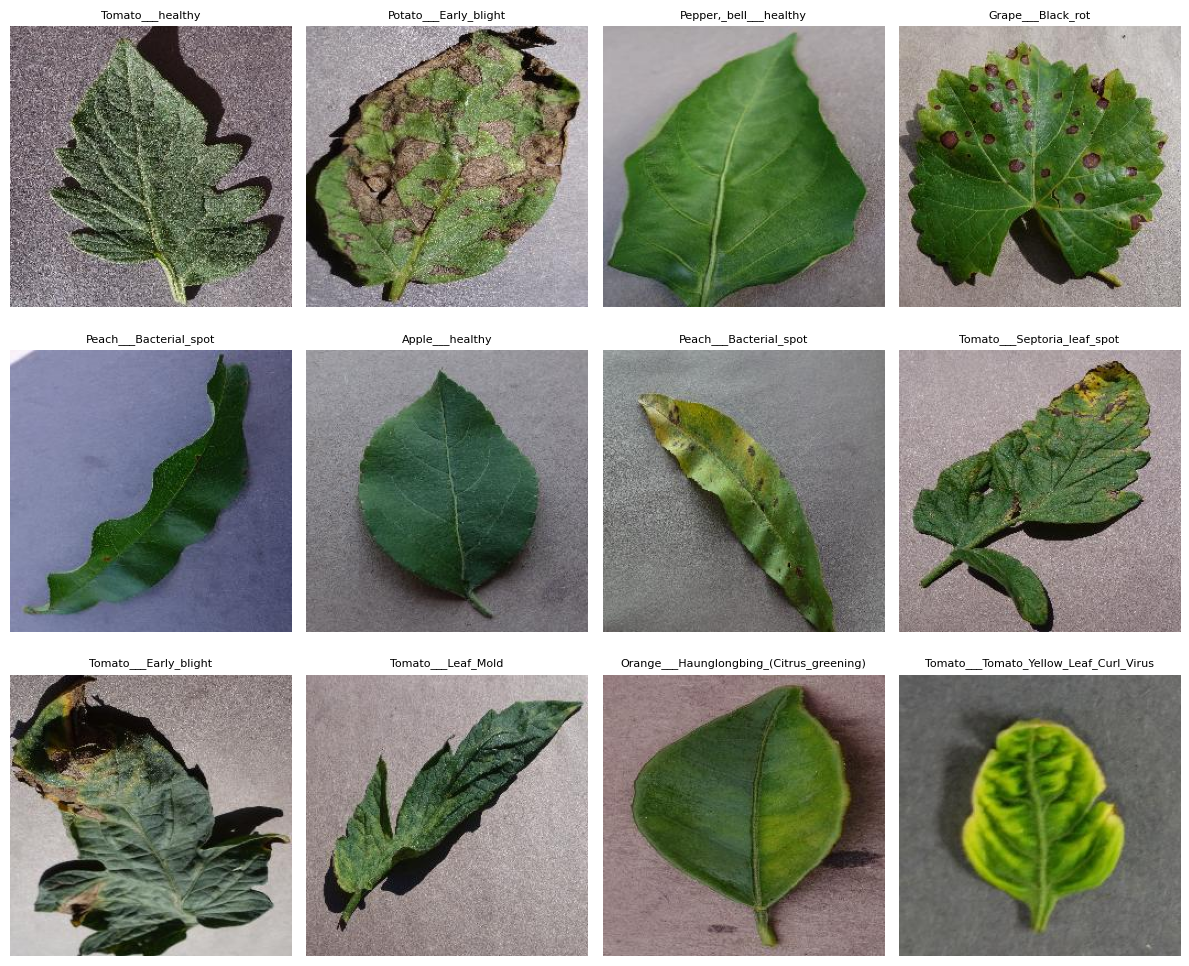

In [ ]:
# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

sample_df = train_df.sample(
    12,
    random_state=42
)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = Image.open(row["image_path"])

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)
    plt.title(row["label"], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CHECK GPU
# ============================================================

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\n✅ GPU detected!")
    for gpu in gpus:
        print(gpu)
else:
    print("\n⚠️ No GPU detected.")
    print("Go to Runtime → Change runtime type → T4 GPU")

TensorFlow version: 2.20.0

✅ GPU detected!
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [ ]:
# ============================================================
# IMAGE CONFIGURATION
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Classes    :", NUM_CLASSES)

Image size : 224
Batch size : 32
Classes    : 38


In [ ]:
# ============================================================
# IMAGE LOADING FUNCTION
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def load_image(image_path, label):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode JPG/PNG image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Convert to float
    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [ ]:
# ============================================================
# CREATE TF.DATA DATASETS
# ============================================================

train_paths = train_df["image_path"].values
train_labels = train_df["label_id"].values

val_paths = val_df["image_path"].values
val_labels = val_df["label_id"].values

test_paths = test_df["image_path"].values
test_labels = test_df["label_id"].values


train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


# Load images
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)


# Shuffle training data
train_dataset = train_dataset.shuffle(
    buffer_size=2000,
    seed=42
)


# Batch
train_dataset = train_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)


# Prefetch
train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    AUTOTUNE
)


print("✅ TensorFlow datasets created!")

✅ TensorFlow datasets created!


In [ ]:
# ============================================================
# CHECK A BATCH
# ============================================================

images, labels = next(
    iter(train_dataset)
)

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image data type   :", images.dtype)

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Image data type   : <dtype: 'float32'>


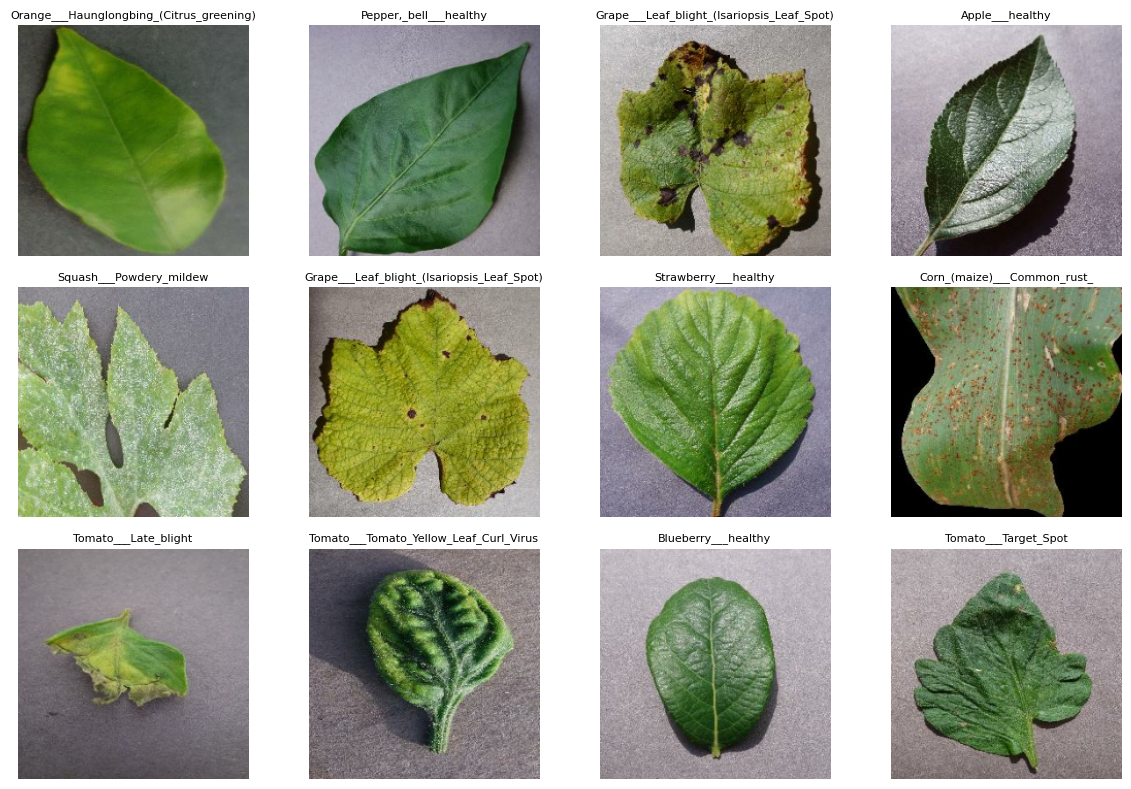

In [ ]:
# ============================================================
# DISPLAY TRAINING BATCH
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        images[i].numpy().astype("uint8")
    )

    label_id = int(labels[i].numpy())

    plt.title(
        index_to_class[label_id],
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# IMPROVED DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.20
    ),

    layers.RandomZoom(
        height_factor=(-0.15, 0.20),
        width_factor=(-0.15, 0.20)
    ),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomContrast(
        0.20
    ),

    layers.RandomBrightness(
        0.15
    )

], name="improved_data_augmentation")

print("✅ Improved data augmentation created")

✅ Improved data augmentation created


In [ ]:
# ============================================================
# BUILD EFFICIENTNETB0 MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Image size
IMG_SIZE = 224

# Number of classes
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

# ------------------------------------------------------------
# Load pretrained EfficientNetB0
# ------------------------------------------------------------

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

print("✅ EfficientNetB0 loaded")


# ------------------------------------------------------------
# Create input
# ------------------------------------------------------------

inputs = layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)


# ------------------------------------------------------------
# Data augmentation
# ------------------------------------------------------------

x = data_augmentation(inputs)


# ------------------------------------------------------------
# EfficientNetB0
# ------------------------------------------------------------

x = base_model(
    x,
    training=False
)


# ------------------------------------------------------------
# Global Average Pooling
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D()(x)


# ------------------------------------------------------------
# Dropout
# ------------------------------------------------------------

x = layers.Dropout(0.30)(x)


# ------------------------------------------------------------
# Final classification layer
# ------------------------------------------------------------

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


# ------------------------------------------------------------
# Create the final model
# ------------------------------------------------------------

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="PlantDisease_EfficientNetB0"
)

print("✅ Model created successfully!")

print("\nModel name:", model.name)
print("Number of output classes:", NUM_CLASSES)

Number of classes: 38
✅ EfficientNetB0 loaded
✅ Model created successfully!

Model name: PlantDisease_EfficientNetB0
Number of output classes: 38


In [ ]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

print("✅ MODEL COMPILED SUCCESSFULLY!")

✅ MODEL COMPILED SUCCESSFULLY!


In [ ]:
# ============================================================
# CHECK MODEL
# ============================================================

model.summary()

Model: "PlantDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ============================================================
# PHASE 1 - TRAIN THE MODEL
# ============================================================

EPOCHS = 10

print("Starting Phase 1 training...")
print("Epochs:", EPOCHS)
print("Number of classes:", NUM_CLASSES)

Starting Phase 1 training...
Epochs: 10
Number of classes: 38


In [ ]:
# ============================================================
# CREATE TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Location where the best model will be saved
checkpoint_path = (
    "/content/drive/MyDrive/plantdisease/"
    "best_plant_disease_model.keras"
)

# Create callbacks
callbacks = [

    # Save the model whenever validation accuracy improves
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    # Stop training if validation loss stops improving
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when progress slows down
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks created successfully!")
print("Model will be saved at:")
print(checkpoint_path)

✅ Callbacks created successfully!
Model will be saved at:
/content/drive/MyDrive/plantdisease/best_plant_disease_model.keras


In [ ]:
# ============================================================
# PHASE 1 - TRAIN MODEL
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks
)

print("✅ Phase 1 training completed!")

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6804 - loss: 1.3158
Epoch 1: val_accuracy improved from None to 0.89836, saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 148s 112ms/step - accuracy: 0.8053 - loss: 0.7922 - val_accuracy: 0.8984 - val_loss: 0.3741 - learning_rate: 0.0010
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8954 - loss: 0.3758
Epoch 2: val_accuracy improved from 0.89836 to 0.91665, saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 141s 111ms/step - accuracy: 0.8997 - loss: 0.3507 - val_accuracy: 0.9166 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms

In [ ]:
# ============================================================
# PHASE 2 - FINE-TUNE EFFICIENTNETB0
# ============================================================

print("==============================================")
print("PHASE 2 - FINE-TUNING")
print("==============================================")

# Make the EfficientNet base model trainable
base_model.trainable = True

# Freeze the first 70% of EfficientNet layers
fine_tune_from = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total EfficientNet layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_from)

trainable_layers = sum(
    1 for layer in base_model.layers
    if layer.trainable
)

print("Trainable EfficientNet layers:", trainable_layers)

PHASE 2 - FINE-TUNING
Total EfficientNet layers: 238
Fine-tuning from layer: 166
Trainable EfficientNet layers: 57


In [ ]:
# ============================================================
# RECOMPILE MODEL FOR FINE-TUNING
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model recompiled for fine-tuning!")

✅ Model recompiled for fine-tuning!


In [ ]:
# ============================================================
# PHASE 2 - FINE-TUNING CALLBACKS
# ============================================================

fine_tune_callbacks = [

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Fine-tuning callbacks created!")

✅ Fine-tuning callbacks created!


In [ ]:
# ============================================================
# PHASE 2 - TRAINING
# ============================================================

FINE_TUNE_EPOCHS = 15

print("==============================================")
print("STARTING PHASE 2 TRAINING")
print("==============================================")

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

print("==============================================")
print("PHASE 2 TRAINING COMPLETED")
print("==============================================")

STARTING PHASE 2 TRAINING
Epoch 1/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9479 - loss: 0.1569
Epoch 1: val_accuracy improved from None to 0.96170, saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 180s 137ms/step - accuracy: 0.9565 - loss: 0.1287 - val_accuracy: 0.9617 - val_loss: 0.1020 - learning_rate: 1.0000e-04
Epoch 2/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9716 - loss: 0.0854
Epoch 2: val_accuracy improved from 0.96170 to 0.97950, saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 162s 134ms/step - accuracy: 0.9732 - loss: 0.0787 - val_accuracy: 0.9795 - val_loss: 0.0628 - learning_rate: 1.0000e-04
Epoch 3/15
11

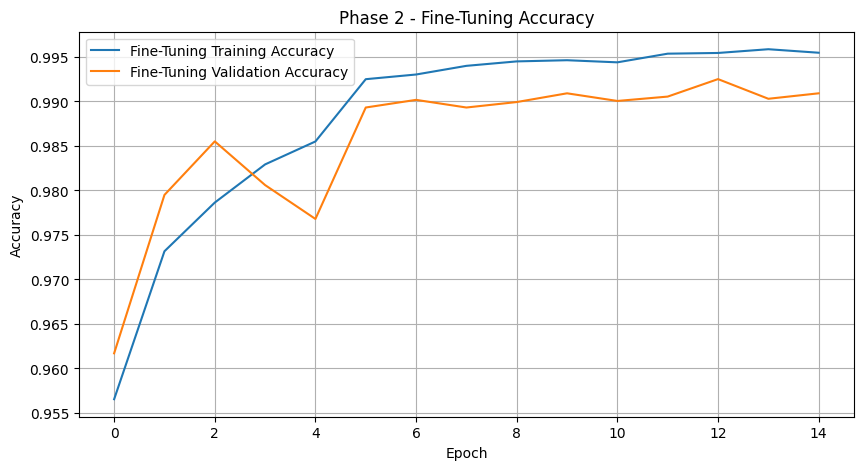

In [ ]:
# ============================================================
# PHASE 2 - FINE-TUNING ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_fine.history["accuracy"],
    label="Fine-Tuning Training Accuracy"
)

plt.plot(
    history_fine.history["val_accuracy"],
    label="Fine-Tuning Validation Accuracy"
)

plt.title("Phase 2 - Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

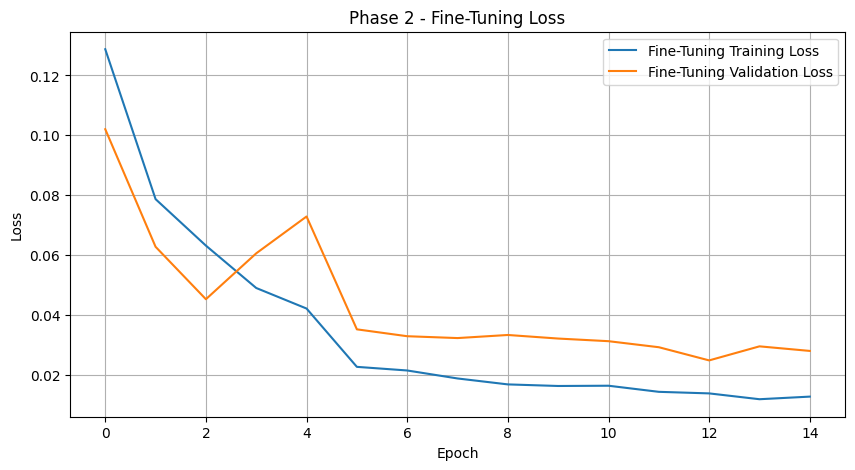

In [ ]:
# ============================================================
# PHASE 2 - FINE-TUNING LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_fine.history["loss"],
    label="Fine-Tuning Training Loss"
)

plt.plot(
    history_fine.history["val_loss"],
    label="Fine-Tuning Validation Loss"
)

plt.title("Phase 2 - Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

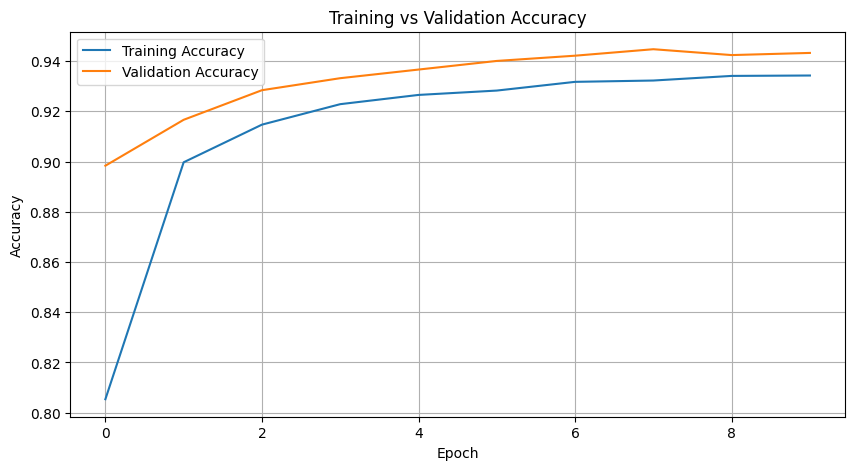

In [ ]:
# ============================================================
# PHASE 1 - TRAINING & VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# LOAD THE BEST FINE-TUNED MODEL
# ============================================================

model = tf.keras.models.load_model(
    checkpoint_path
)

print("✅ Best fine-tuned model loaded successfully!")

✅ Best fine-tuned model loaded successfully!


In [ ]:
# ============================================================
# FINAL TEST EVALUATION AFTER FINE-TUNING
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n==============================================")
print("FINAL FINE-TUNED MODEL RESULTS")
print("==============================================")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("==============================================")

255/255 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step - accuracy: 0.9937 - loss: 0.0180

FINAL FINE-TUNED MODEL RESULTS
Test Accuracy : 99.37%
Test Loss     : 0.0180


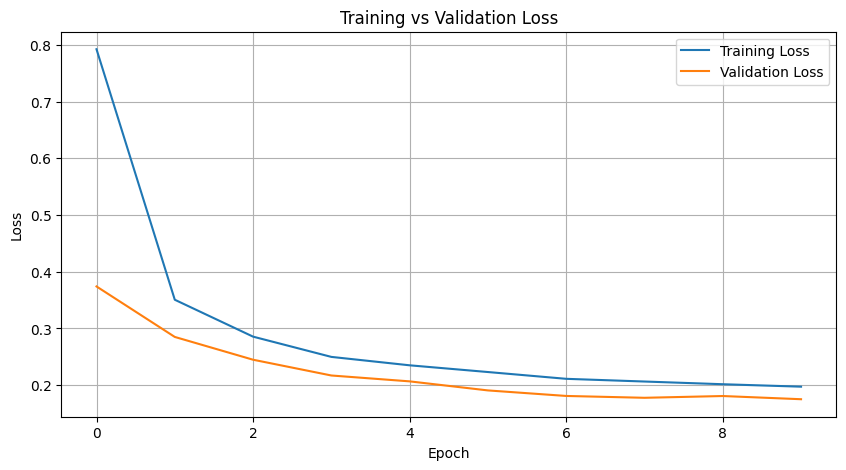

In [ ]:
# ============================================================
# PHASE 1 - TRAINING & VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

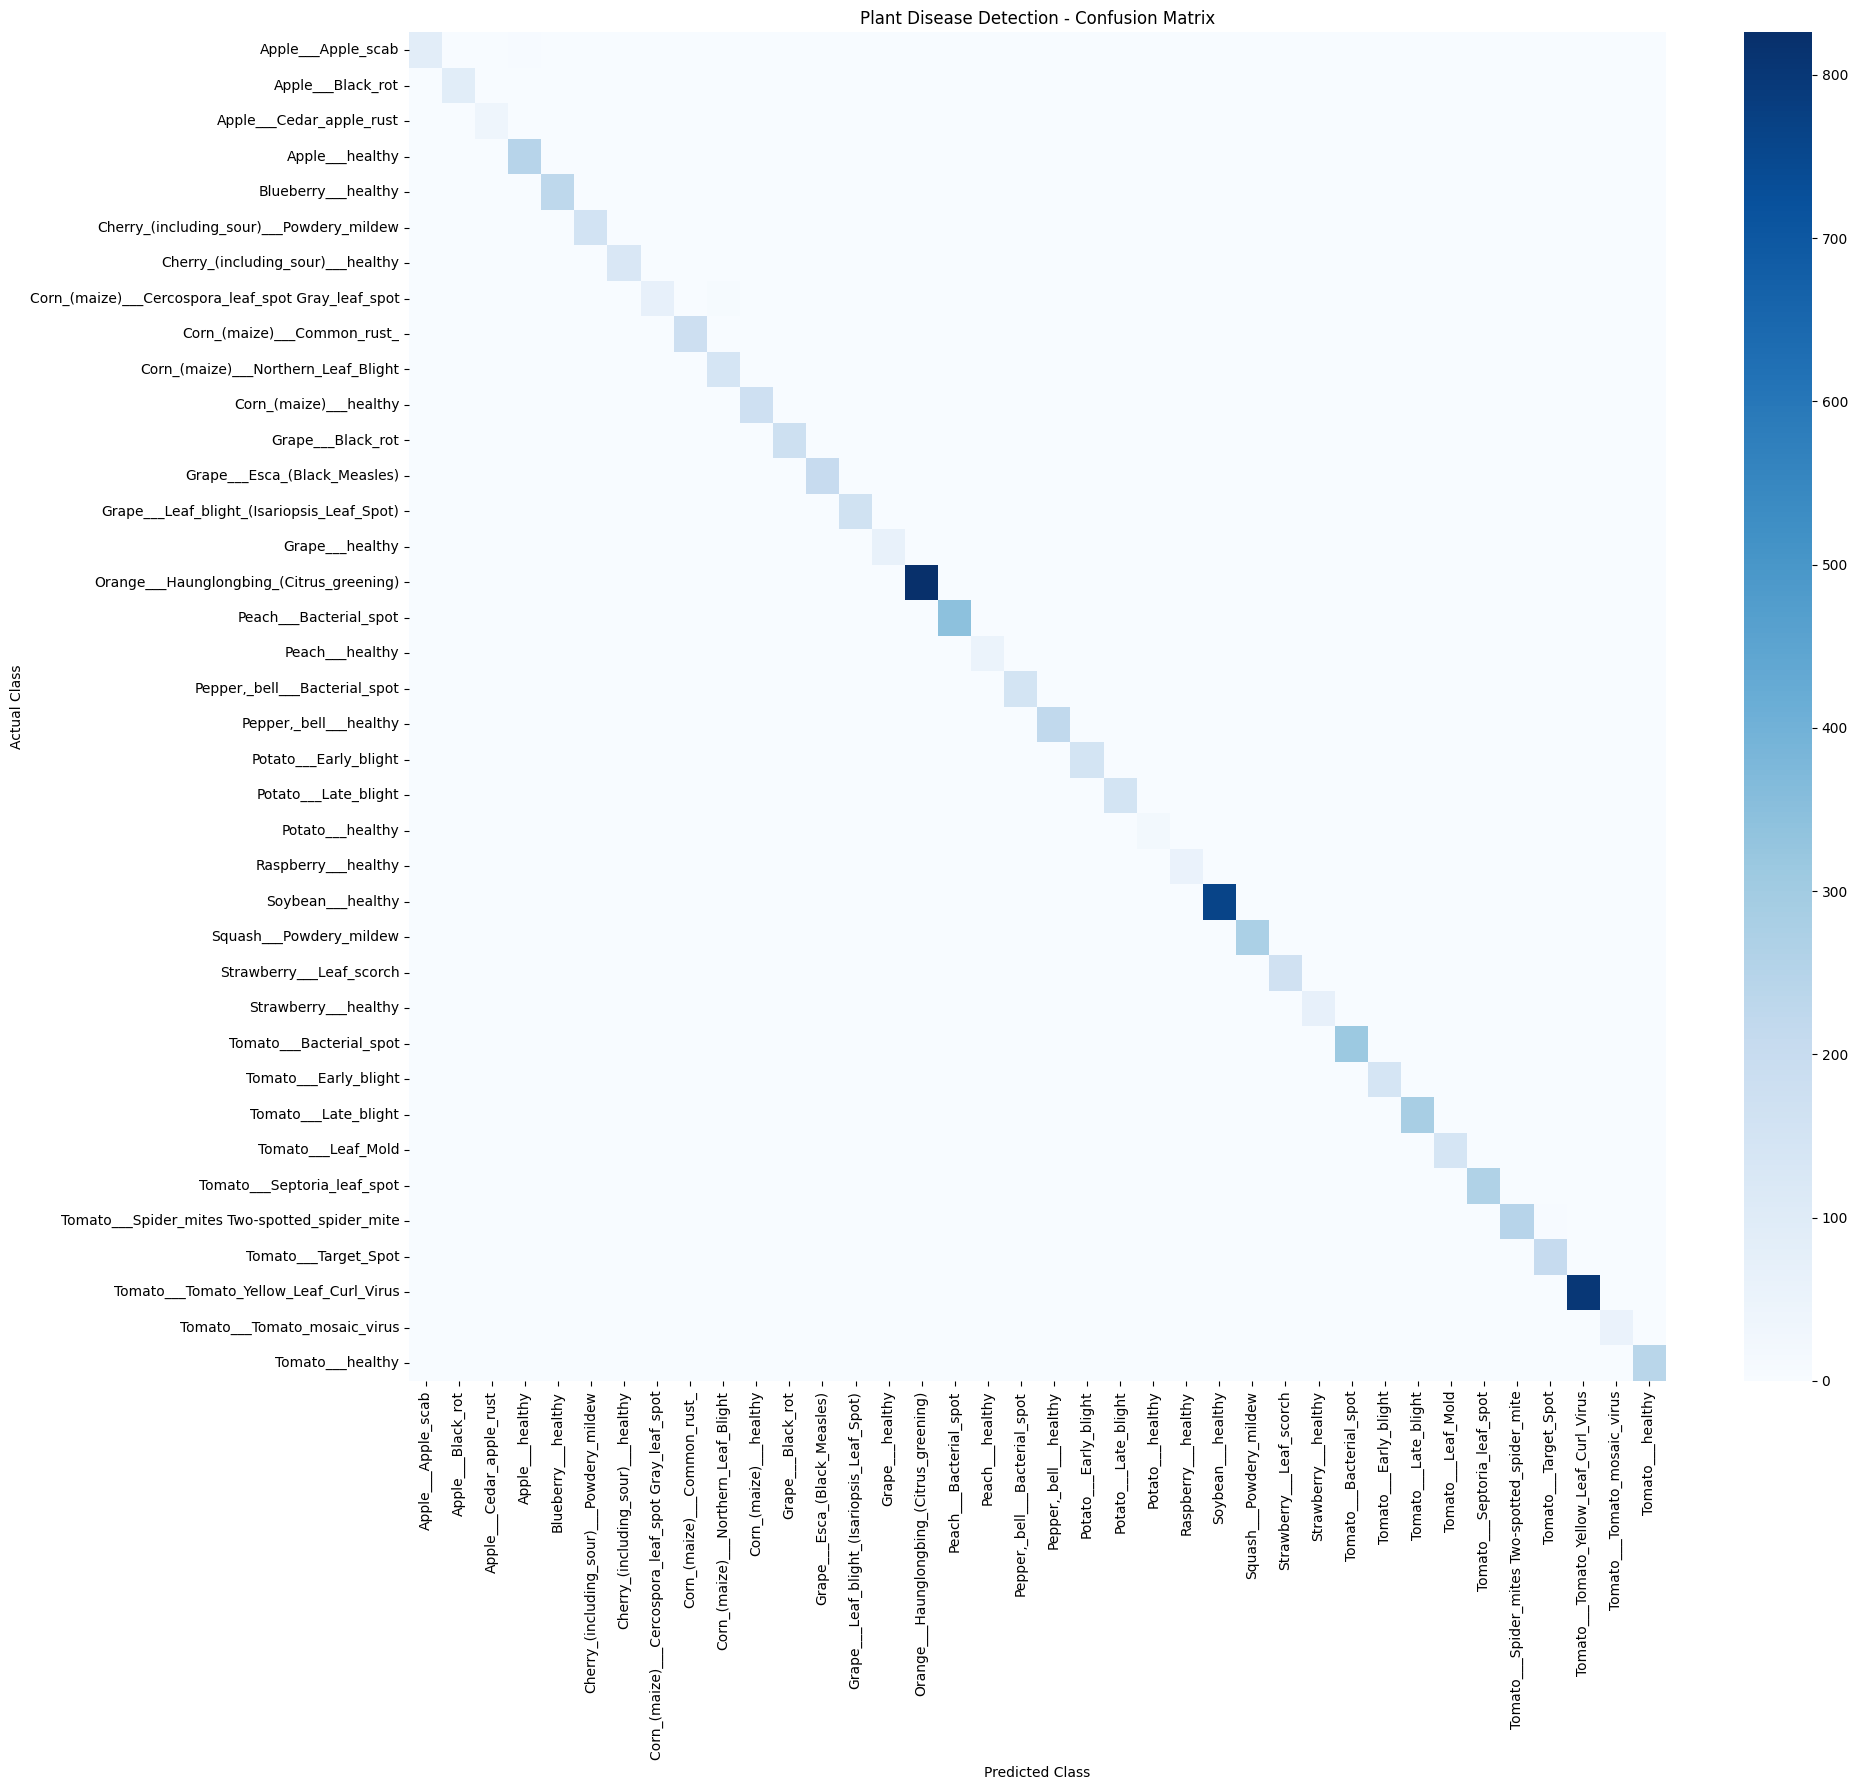

Confusion Matrix generated successfully!


In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get the true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(20, 18))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Plant Disease Detection - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("Confusion Matrix generated successfully!")

In [ ]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("============================================================")
print("PLANT DISEASE CLASSIFICATION REPORT")
print("============================================================")

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

PLANT DISEASE CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9574    0.9783        94
                                 Apple___Black_rot     0.9894    1.0000    0.9947        93
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        41
                                   Apple___healthy     0.9723    1.0000    0.9860       246
                               Blueberry___healthy     1.0000    1.0000    1.0000       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       158
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9589    0.9091    0.9333        77
                       Corn_(maize)___Common_rust_     0.9944    1.0000    0.9972       179
               Corn_(maize)___Northern_Leaf

In [ ]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 60)
print("        SMART PLANT DISEASE DETECTION SYSTEM")
print("=" * 60)

print("\nMODEL PERFORMANCE")
print("-" * 60)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

print("\nMODEL INFORMATION")
print("-" * 60)
print("Model         : EfficientNetB0")
print("Number of Classes : 38")
print("Input Image Size  : 224 x 224")
print("Task          : Plant Disease Classification")

print("\nSYSTEM FEATURES")
print("-" * 60)
print("✓ Plant disease detection")
print("✓ Confidence score")
print("✓ Disease description")
print("✓ Recommended treatment")
print("✓ Prevention guidelines")
print("✓ Image-based prediction")

print("\n" + "=" * 60)
print("          PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

        SMART PLANT DISEASE DETECTION SYSTEM

MODEL PERFORMANCE
------------------------------------------------------------
Test Accuracy : 99.37%
Test Loss     : 0.0180

MODEL INFORMATION
------------------------------------------------------------
Model         : EfficientNetB0
Number of Classes : 38
Input Image Size  : 224 x 224
Task          : Plant Disease Classification

SYSTEM FEATURES
------------------------------------------------------------
✓ Plant disease detection
✓ Confidence score
✓ Disease description
✓ Recommended treatment
✓ Prevention guidelines
✓ Image-based prediction

          PROJECT COMPLETED SUCCESSFULLY


In [ ]:
print("Model exists:", 'model' in globals())
print("Class names exist:", 'class_names' in globals())

if 'model' in globals():
    print("Model type:", type(model))

if 'class_names' in globals():
    print("Number of classes:", len(class_names))
    print("First classes:", class_names[:5])

Model exists: True
Class names exist: True
Model type: <class 'keras.src.models.functional.Functional'>
Number of classes: 38
First classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [ ]:
import os

model_path = "/content/drive/MyDrive/plantdisease/best_plant_disease_model.keras"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("✅ Model saved successfully!")
    print("Model path:", model_path)
    print("File size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")
else:
    print("❌ Model file not found!")

Model exists: True
✅ Model saved successfully!
Model path: /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras
File size: 40.16 MB


STREAMLIT COMMANDS

In [ ]:
!pip install streamlit -q

In [ ]:
!cp /content/drive/MyDrive/plantdisease/best_plant_disease_model.keras /content/best_plant_disease_model.keras

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image


# ============================================================
# PAGE SETTINGS
# ============================================================

st.set_page_config(
    page_title="Smart Plant Disease Detection",
    page_icon="🌿"
)


# ============================================================
# TITLE
# ============================================================

st.title("🌿 Smart Plant Disease Detection")

st.write(
    "Upload a plant leaf image to detect the possible disease "
    "and get basic treatment and prevention information."
)

st.info(
    "For best results, upload a clear image showing the plant leaf."
)


# ============================================================
# MODEL
# ============================================================

MODEL_PATH = "/content/best_plant_disease_model.keras"


@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)


model = load_model()


# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Blueberry___healthy",
    "Cherry_(including_sour)___Powdery_mildew",
    "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)",
    "Peach___Bacterial_spot",
    "Peach___healthy",
    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Raspberry___healthy",
    "Soybean___healthy",
    "Squash___Powdery_mildew",
    "Strawberry___Leaf_scorch",
    "Strawberry___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]


# ============================================================
# TREATMENT INFORMATION
# ============================================================

treatment_info = {

    "Apple___Apple_scab": {
        "disease": "Apple Scab",
        "description": "A fungal disease that causes dark olive or brown spots on apple leaves and fruits.",
        "treatment": "Remove and destroy infected leaves and fruits. Improve air circulation and avoid overhead watering. Use an appropriate fungicide according to local agricultural recommendations.",
        "prevention": "Keep the area clean, remove fallen infected leaves, prune overcrowded branches and use disease-resistant varieties when available."
    },

    "Apple___Black_rot": {
        "disease": "Apple Black Rot",
        "description": "A fungal disease that can cause dark lesions on leaves and fruit rot.",
        "treatment": "Remove infected plant material and dead wood. Maintain good airflow and apply an appropriate fungicide when recommended.",
        "prevention": "Remove mummified fruits and dead branches and keep the orchard clean."
    },

    "Apple___Cedar_apple_rust": {
        "disease": "Apple Cedar Apple Rust",
        "description": "A fungal disease that produces yellow-orange spots on apple leaves.",
        "treatment": "Remove heavily infected material and use an appropriate fungicide according to local recommendations.",
        "prevention": "Maintain good airflow and manage nearby alternate hosts when practical."
    },

    "Apple___healthy": {
        "disease": "Apple Healthy",
        "description": "The leaf appears healthy with no major disease detected.",
        "treatment": "No disease treatment is required.",
        "prevention": "Continue proper watering, nutrition, pruning and regular monitoring."
    },

    "Blueberry___healthy": {
        "disease": "Blueberry Healthy",
        "description": "The blueberry leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper soil moisture, nutrition and regular monitoring."
    },

    "Cherry_(including_sour)___Powdery_mildew": {
        "disease": "Cherry Powdery Mildew",
        "description": "A fungal disease that produces a white powder-like growth on leaves and shoots.",
        "treatment": "Remove severely affected parts and improve air circulation. Use an appropriate fungicide according to local recommendations.",
        "prevention": "Avoid excessive nitrogen, maintain airflow and monitor new growth regularly."
    },

    "Cherry_(including_sour)___healthy": {
        "disease": "Cherry Healthy",
        "description": "The cherry leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Continue regular watering, nutrition and disease monitoring."
    },

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
        "disease": "Corn Cercospora Leaf Spot / Gray Leaf Spot",
        "description": "A fungal disease that causes gray or brown lesions on maize leaves.",
        "treatment": "Remove heavily infected plant debris where practical and use appropriate disease management practices or fungicides according to local recommendations.",
        "prevention": "Use crop rotation, resistant varieties and good field sanitation."
    },

    "Corn_(maize)___Common_rust_": {
        "disease": "Corn Common Rust",
        "description": "A fungal disease that produces rust-colored spots on maize leaves.",
        "treatment": "Monitor disease development and use resistant varieties or an appropriate fungicide when necessary.",
        "prevention": "Use resistant varieties and maintain proper crop management."
    },

    "Corn_(maize)___Northern_Leaf_Blight": {
        "disease": "Corn Northern Leaf Blight",
        "description": "A fungal disease that produces long gray-green or brown lesions on maize leaves.",
        "treatment": "Use resistant varieties and appropriate fungicide management when recommended.",
        "prevention": "Practice crop rotation, remove infected residue where practical and use resistant varieties."
    },

    "Corn_(maize)___healthy": {
        "disease": "Corn Healthy",
        "description": "The maize leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Continue proper irrigation, nutrition and regular monitoring."
    },

    "Grape___Black_rot": {
        "disease": "Grape Black Rot",
        "description": "A fungal disease that causes dark lesions and can damage grape berries.",
        "treatment": "Remove infected leaves and fruit. Improve canopy airflow and use an appropriate fungicide according to local recommendations.",
        "prevention": "Remove infected plant material, maintain good canopy management and avoid prolonged leaf wetness."
    },

    "Grape___Esca_(Black_Measles)": {
        "disease": "Grape Esca / Black Measles",
        "description": "A complex grape disease that can cause leaf symptoms and fruit damage.",
        "treatment": "Remove severely affected plant material and manage infected vines according to local viticulture recommendations.",
        "prevention": "Use healthy planting material, maintain vine health and prevent wounds where possible."
    },

    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": {
        "disease": "Grape Leaf Blight (Isariopsis Leaf Spot)",
        "description": "A fungal leaf disease that causes brown or dark lesions and can lead to leaf damage.",
        "treatment": "Remove severely infected leaves and improve air circulation around the vines. Avoid prolonged leaf wetness and use an appropriate fungicide according to local agricultural recommendations.",
        "prevention": "Maintain good canopy ventilation, remove infected plant debris and monitor leaves regularly."
    },

    "Grape___healthy": {
        "disease": "Grape Healthy",
        "description": "The grape leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper irrigation, nutrition, pruning and regular disease monitoring."
    },

    "Orange___Haunglongbing_(Citrus_greening)": {
        "disease": "Citrus Huanglongbing (Citrus Greening)",
        "description": "A serious citrus disease that can cause yellowing and reduced plant productivity.",
        "treatment": "There is no simple curative treatment for infected trees. Follow local agricultural guidance for managing infected trees and controlling the insect vector.",
        "prevention": "Use certified healthy planting material and manage the insect vector according to local recommendations."
    },

    "Peach___Bacterial_spot": {
        "disease": "Peach Bacterial Spot",
        "description": "A bacterial disease that causes spots and lesions on peach leaves and fruit.",
        "treatment": "Remove severely affected material and use appropriate bacterial disease management practices according to local recommendations.",
        "prevention": "Use resistant varieties where available and maintain good orchard sanitation."
    },

    "Peach___healthy": {
        "disease": "Peach Healthy",
        "description": "The peach leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper watering, nutrition and regular monitoring."
    },

    "Pepper,_bell___Bacterial_spot": {
        "disease": "Pepper Bell Bacterial Spot",
        "description": "A bacterial disease that causes spots on pepper leaves and fruit.",
        "treatment": "Remove severely infected material and avoid overhead irrigation. Follow local recommendations for bacterial disease control.",
        "prevention": "Use clean planting material, maintain sanitation and avoid working with wet plants."
    },

    "Pepper,_bell___healthy": {
        "disease": "Pepper Bell Healthy",
        "description": "The pepper leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain good irrigation, nutrition and regular monitoring."
    },

    "Potato___Early_blight": {
        "disease": "Potato Early Blight",
        "description": "A fungal disease that causes dark circular lesions on potato leaves.",
        "treatment": "Remove infected plant debris and improve plant airflow. Use an appropriate fungicide according to local agricultural recommendations.",
        "prevention": "Practice crop rotation, maintain plant nutrition and avoid prolonged leaf wetness."
    },

    "Potato___Late_blight": {
        "disease": "Potato Late Blight",
        "description": "A destructive disease that causes dark water-soaked lesions on leaves.",
        "treatment": "Remove severely infected plant material and seek timely local agricultural guidance. Appropriate fungicide management may be required.",
        "prevention": "Use disease-free planting material, resistant varieties where available and avoid prolonged leaf wetness."
    },

    "Potato___healthy": {
        "disease": "Potato Healthy",
        "description": "The potato leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper irrigation, nutrition and regular monitoring."
    },

    "Raspberry___healthy": {
        "disease": "Raspberry Healthy",
        "description": "The raspberry leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper watering, nutrition, pruning and monitoring."
    },

    "Soybean___healthy": {
        "disease": "Soybean Healthy",
        "description": "The soybean leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper irrigation, nutrition and regular crop monitoring."
    },

    "Squash___Powdery_mildew": {
        "disease": "Squash Powdery Mildew",
        "description": "A fungal disease that produces white powder-like growth on leaves.",
        "treatment": "Remove severely affected leaves and improve air circulation. Use an appropriate fungicide according to local recommendations.",
        "prevention": "Maintain good spacing and airflow and avoid excessive humidity around leaves."
    },

    "Strawberry___Leaf_scorch": {
        "disease": "Strawberry Leaf Scorch",
        "description": "A disease that produces reddish or brown lesions and scorched areas on strawberry leaves.",
        "treatment": "Remove severely affected leaves and maintain good plant sanitation. Follow local agricultural recommendations for disease management.",
        "prevention": "Remove infected debris, maintain airflow and avoid prolonged leaf wetness."
    },

    "Strawberry___healthy": {
        "disease": "Strawberry Healthy",
        "description": "The strawberry leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper watering, nutrition and regular monitoring."
    },

    "Tomato___Bacterial_spot": {
        "disease": "Tomato Bacterial Spot",
        "description": "A bacterial disease that causes dark spots on tomato leaves and fruit.",
        "treatment": "Remove severely infected material and avoid overhead watering. Follow local recommendations for bacterial disease management.",
        "prevention": "Use clean planting material, maintain sanitation and avoid handling plants when they are wet."
    },

    "Tomato___Early_blight": {
        "disease": "Tomato Early Blight",
        "description": "A fungal disease that produces dark concentric lesions on tomato leaves.",
        "treatment": "Remove infected leaves and plant debris. Improve airflow and use an appropriate fungicide according to local recommendations.",
        "prevention": "Practice crop rotation, maintain good spacing and avoid prolonged leaf wetness."
    },

    "Tomato___Late_blight": {
        "disease": "Tomato Late Blight",
        "description": "A serious disease that produces dark water-soaked lesions on tomato leaves.",
        "treatment": "Remove severely infected plant material and seek timely local agricultural guidance. Appropriate fungicide management may be required.",
        "prevention": "Use disease-free plants, improve airflow and avoid prolonged leaf wetness."
    },

    "Tomato___Leaf_Mold": {
        "disease": "Tomato Leaf Mold",
        "description": "A fungal disease that commonly develops under humid conditions.",
        "treatment": "Remove affected leaves and improve ventilation. Reduce humidity around foliage and use an appropriate fungicide when recommended.",
        "prevention": "Improve greenhouse ventilation and avoid excessive leaf moisture."
    },

    "Tomato___Septoria_leaf_spot": {
        "disease": "Tomato Septoria Leaf Spot",
        "description": "A fungal disease that causes many small spots on tomato leaves.",
        "treatment": "Remove affected leaves and plant debris. Improve airflow and use an appropriate fungicide according to local recommendations.",
        "prevention": "Practice crop rotation, maintain sanitation and avoid overhead watering."
    },

    "Tomato___Spider_mites Two-spotted_spider_mite": {
        "disease": "Tomato Two-Spotted Spider Mite",
        "description": "A pest infestation that can cause stippling, yellowing and leaf damage.",
        "treatment": "Inspect the underside of leaves and use appropriate integrated pest management practices. Follow local recommendations for mite control.",
        "prevention": "Monitor plants regularly, reduce plant stress and encourage beneficial organisms where appropriate."
    },

    "Tomato___Target_Spot": {
        "disease": "Tomato Target Spot",
        "description": "A fungal disease that causes circular target-like lesions on leaves and fruit.",
        "treatment": "Remove infected leaves and improve airflow. Use an appropriate fungicide according to local recommendations.",
        "prevention": "Maintain plant spacing, sanitation and avoid prolonged leaf wetness."
    },

    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
        "disease": "Tomato Yellow Leaf Curl Virus",
        "description": "A viral disease that can cause leaf curling, yellowing and reduced plant growth.",
        "treatment": "There is no direct cure for an infected plant. Remove severely infected plants where appropriate and manage the insect vector according to local recommendations.",
        "prevention": "Use healthy seedlings and control the insect vector using integrated pest management."
    },

    "Tomato___Tomato_mosaic_virus": {
        "disease": "Tomato Mosaic Virus",
        "description": "A viral disease that can cause mosaic patterns and reduced plant growth.",
        "treatment": "Remove severely infected plants and maintain strict sanitation. There is no direct cure for an infected plant.",
        "prevention": "Use clean planting material, disinfect tools and avoid spreading plant sap between plants."
    },

    "Tomato___healthy": {
        "disease": "Tomato Healthy",
        "description": "The tomato leaf appears healthy.",
        "treatment": "No disease treatment is required.",
        "prevention": "Maintain proper irrigation, nutrition, airflow and regular monitoring."
    }
}


# ============================================================
# IMAGE UPLOAD
# ============================================================

st.subheader("Upload a Plant Leaf")

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)


# ============================================================
# PREDICTION
# ============================================================

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Leaf",
        width=400
    )

    if st.button("Detect Disease"):

        with st.spinner("Analyzing image..."):

            # Same preprocessing used during training
            img_array = np.array(
                image,
                dtype=np.float32
            )

            img_array = tf.image.resize(
                img_array,
                [224, 224]
            ).numpy()

            img_array = np.expand_dims(
                img_array,
                axis=0
            )

            predictions = model.predict(
                img_array,
                verbose=0
            )

            predicted_index = np.argmax(
                predictions[0]
            )

            confidence = (
                float(predictions[0][predicted_index]) * 100
            )

        # ----------------------------------------------------
        # CONFIDENCE CHECK
        # ----------------------------------------------------

        if confidence < 70:

            st.warning(
                "The model is not confident about this image."
            )

            st.write(
                f"Confidence: {confidence:.2f}%"
            )

            st.info(
                "Please upload a clear image of a plant leaf."
            )

        else:

            disease = class_names[predicted_index]

            readable_name = (
                disease
                .replace("___", " - ")
                .replace("_", " ")
            )

            info = treatment_info.get(disease)

            # ------------------------------------------------
            # RESULT
            # ------------------------------------------------

            st.success("Prediction completed!")

            st.subheader("Prediction Result")

            st.write(f"**Disease:** {readable_name}")
            st.write(f"**Confidence:** {confidence:.2f}%")

            if info:

                st.subheader("Disease Information")

                st.write("**Description**")
                st.write(info["description"])

                st.write("**Recommended Treatment**")
                st.write(info["treatment"])

                st.write("**Prevention**")
                st.write(info["prevention"])


# ============================================================
# DISCLAIMER
# ============================================================

st.divider()

st.caption(
    "This system is developed for educational purposes."
)

st.caption(
    "Model trained using the PlantVillage dataset."
)

Overwriting app.py


In [ ]:
!cat /content/streamlit.log

In [ ]:
!streamlit run /content/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

CLOUD RUN DEPLOYMENT COMMANDS

In [ ]:
import os

os.makedirs("/content/plant-disease-app", exist_ok=True)

print("Deployment folder created.")

Deployment folder created.


In [ ]:
import shutil
import os

source_model = "/content/drive/MyDrive/plantdisease/best_plant_disease_model.keras"
destination_model = "/content/plant-disease-app/best_plant_disease_model.keras"

shutil.copy2(source_model, destination_model)

print("Model copied successfully.")
print("Model exists:", os.path.exists(destination_model))
print("Model size:", os.path.getsize(destination_model), "bytes")

Model copied successfully.
Model exists: True
Model size: 42108124 bytes


In [ ]:
import shutil
import os

source_app = "/content/app.py"
destination_app = "/content/plant-disease-app/app.py"

shutil.copy2(source_app, destination_app)

print("app.py copied successfully.")
print("File exists:", os.path.exists(destination_app))

app.py copied successfully.
File exists: True


In [ ]:
%%writefile /content/plant-disease-app/requirements.txt

streamlit
tensorflow
numpy
Pillow

Writing /content/plant-disease-app/requirements.txt


In [ ]:
import os

folder = "/content/plant-disease-app"

print("Files in deployment folder:")
for file in os.listdir(folder):
    print("-", file)

Files in deployment folder:
- app.py
- best_plant_disease_model.keras
- requirements.txt


In [ ]:
app_path = "/content/plant-disease-app/app.py"

with open(app_path, "r") as f:
    code = f.read()

code = code.replace(
    'MODEL_PATH = "/content/best_plant_disease_model.keras"',
    'MODEL_PATH = "best_plant_disease_model.keras"'
)

with open(app_path, "w") as f:
    f.write(code)

print("Model path updated for Google Cloud.")

Model path updated for Google Cloud.


In [ ]:
app_path = "/content/plant-disease-app/app.py"

with open(app_path, "r") as f:
    code = f.read()

for line in code.splitlines():
    if "MODEL_PATH" in line:
        print(line)

MODEL_PATH = "best_plant_disease_model.keras"
    return tf.keras.models.load_model(MODEL_PATH)


In [8]:
import os
import shutil

# Create deployment folder
folder = "/content/plant-disease-app"
os.makedirs(folder, exist_ok=True)

# Copy the trained model from Google Drive
shutil.copy(
    "/content/drive/MyDrive/plantdisease/best_plant_disease_model.keras",
    folder
)

print("✅ Deployment folder created")
print("Files currently in folder:")
print(os.listdir(folder))

✅ Deployment folder created
Files currently in folder:
['best_plant_disease_model.keras']
